<a href="https://colab.research.google.com/github/shivanshsingh-123/CODSOFT-INTERNSHIP/blob/main/TitanicSurvival.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Titanic-Dataset.csv to Titanic-Dataset.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [ ]:
df  = pd.read_csv('Titanic-Dataset.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [ ]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df['Age'] = df.groupby(['Pclass', 'Sex'])['Age'].transform(lambda x: x.fillna(x.median()))
df.drop(columns=['Cabin'], errors= 'ignore', inplace = True)
print(df.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


In [ ]:
df.drop(columns=['PassengerId', 'Name', 'Ticket'], errors= 'ignore', inplace=True)
df['Sex'] = df['Sex'].map({'male':0, 'female': 1})
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)

df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,3,0,22.0,1,0,7.2500,False,True
1,1,1,1,38.0,1,0,71.2833,False,False
2,1,3,1,26.0,0,0,7.9250,False,True
3,1,1,1,35.0,1,0,53.1000,False,True
4,0,3,0,35.0,0,0,8.0500,False,True


In [ ]:
x = df.drop(columns=['Survived'])
y = df['Survived']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print(f"Training features shape:{x_train.shape}")
print(f"Testing features shape: {x_test.shape}")

Training features shape:(712, 8)
Testing features shape: (179, 8)


In [ ]:
model = LogisticRegression(max_iter=1000)
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}\n")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy Score: 0.8212

Confusion Matrix:
[[92 13]
 [19 55]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.88      0.85       105
           1       0.81      0.74      0.77        74

    accuracy                           0.82       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



# Feature Engineering & Scaling
> To improve model accuracy beyond 82%

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

In [ ]:
df_fe = pd.read_csv("Titanic-Dataset.csv")

In [ ]:
df_fe["Embarked"] = df_fe["Embarked"].fillna(df_fe["Embarked"].mode()[0])
df_fe["Age"] = df_fe.groupby(["Pclass", "Sex"])["Age"].transform(
    lambda x: x.fillna(x.median())
)

In [ ]:
df_fe["Title"] = df_fe["Name"].str.extract(" ([A-Za-z]+)\.", expand=False)
df_fe["Title"] = df_fe["Title"].replace(
    [
        "Lady",
        "Countess",
        "Capt",
        "Col",
        "Don",
        "Dr",
        "Major",
        "Rev",
        "Sir",
        "Jonkheer",
        "Dona",
    ],
    "Rare",
)
df_fe["Title"] = df_fe["Title"].replace(
    {"Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs"}
)

df_fe["FamilySize"] = df_fe["SibSp"] + df_fe["Parch"] + 1
df_fe["IsAlone"] = (df_fe["FamilySize"] == 1).astype(int)

<>:1: SyntaxWarning: invalid escape sequence '\.'
<>:1: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipykernel_1115/122169906.py:1: SyntaxWarning: invalid escape sequence '\.'
  df_fe["Title"] = df_fe["Name"].str.extract(" ([A-Za-z]+)\.", expand=False)


In [ ]:
df_fe.drop(
    columns=["PassengerId", "Name", "Ticket", "Cabin"],
    errors="ignore",
    inplace=True,
)

In [ ]:
df_fe["Sex"] = df_fe["Sex"].map({"male": 0, "female": 1})
df_fe = pd.get_dummies(df_fe, columns=["Embarked", "Title"], drop_first=True)

In [ ]:
X = df_fe.drop(columns=["Survived"])
y = df_fe["Survived"]
x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
scaler = StandardScaler()
x_train[["Age", "Fare"]] = scaler.fit_transform(x_train[["Age", "Fare"]])
x_test[["Age", "Fare"]] = scaler.transform(x_test[["Age", "Fare"]])

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=100, max_depth=5, random_state=42
)
rf_model.fit(x_train, y_train)

rf_pred = rf_model.predict(x_test)
print(f"Random Forest Accuracy: {accuracy_score(y_test, rf_pred):.4f}\n")
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.8268

              precision    recall  f1-score   support

           0       0.84      0.88      0.86       105
           1       0.81      0.76      0.78        74

    accuracy                           0.83       179
   macro avg       0.82      0.82      0.82       179
weighted avg       0.83      0.83      0.83       179



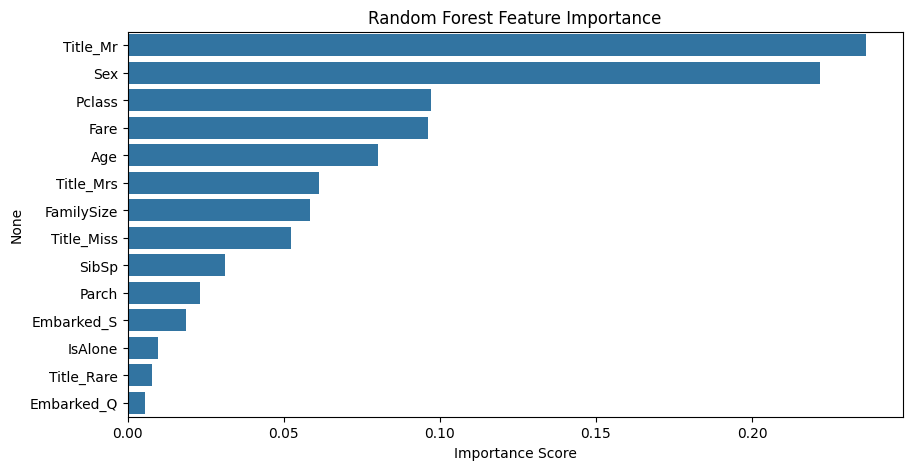

In [ ]:
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10, 5))
sns.barplot(x=importances.values, y=importances.index)
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance Score")
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7, 10],
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5, scoring='accuracy')
grid_search.fit(x_train, y_train)

best_rf = grid_search.best_estimator_
best_pred = best_rf.predict(x_test)

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Tuned Random Forest Accuracy: {accuracy_score(y_test, best_pred):.4f}")

Best Parameters: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 200}
Tuned Random Forest Accuracy: 0.8268


In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

/tmp/ipykernel_1115/1239864259.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
/tmp/ipykernel_1115/1239864259.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_1115/1239864259.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(["Male", "Female"])
/tmp/ipykernel_1115/1239864259.py:10: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
/tmp/ipykernel_1115/1239864259.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_1115/1239864

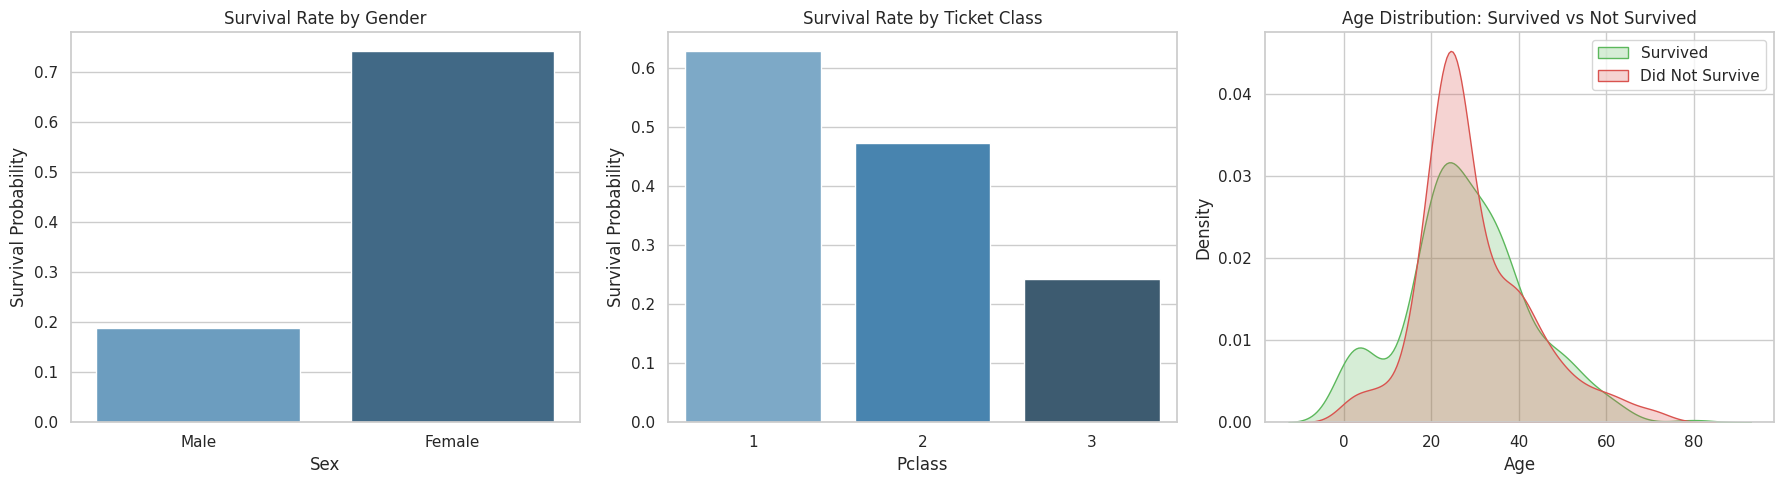

In [ ]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.barplot(
    x="Sex", y="Survived", data=df_fe, ax=axes[0], palette="Blues_d", ci=None
)
axes[0].set_title("Survival Rate by Gender")
axes[0].set_xticklabels(["Male", "Female"])
axes[0].set_ylabel("Survival Probability")

sns.barplot(
    x="Pclass", y="Survived", data=df_fe, ax=axes[1], palette="Blues_d", ci=None
)
axes[1].set_title("Survival Rate by Ticket Class")
axes[1].set_ylabel("Survival Probability")

sns.kdeplot(
    data=df_fe,
    x="Age",
    hue="Survived",
    common_norm=False,
    shade=True,
    ax=axes[2],
    palette=["#d9534f", "#5cb85c"],
)
axes[2].set_title("Age Distribution: Survived vs Not Survived")
axes[2].legend(["Survived", "Did Not Survive"])

plt.tight_layout()
plt.show()